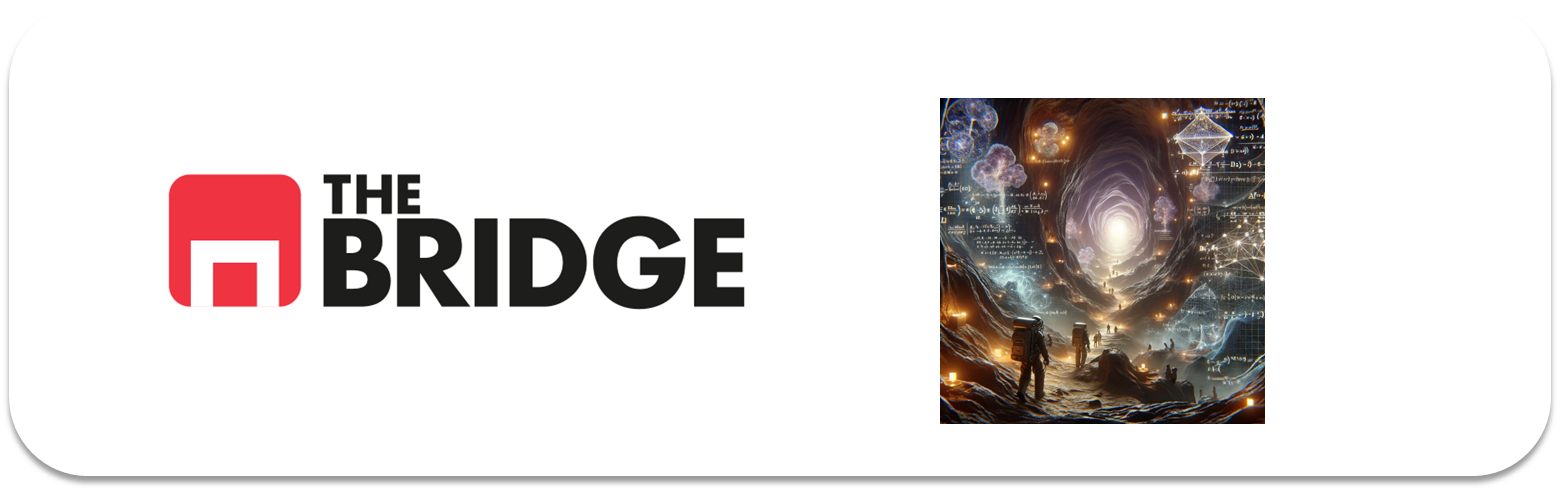

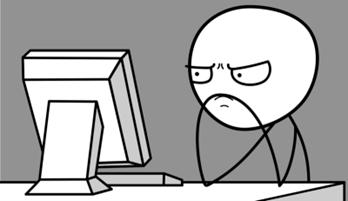

Para ejercitarte y afianzar lo aprendido sobre **Keras y DL**, completa los siguientes ejercicios. Recuerda que necesitarás datos que están en el directorio data que acompaña al notebook (búscalo en el repositorio de ejercicios)
  
La solución a los mismos las tienes ya, intenta no mirarlos de primeras pero no dejes de hacerlo cuando hayas terminado por si te pudieran aportar.

### Predecir eficiencia de gasolina

En este conjuntos de ejercicios vamos a trabajar sobre el set de datos clasico [Auto MPG](https://archive.ics.uci.edu/ml/datasets/auto+mpg) para construir un modelo DL para predecir el consumo de vehiculos de 1970 y 1980. Para hacer esto proveeremos el modelo con una descripcion de muchos automoviles de ese periodo. Esta descripcion incluye atributos como: Cilindros, desplazamiento, potencia y peso.

El objetivo de este ejercicio es predecir el target miles per galon (MPG), que vendría a representar las millas por galón de combustible.

Para la construcción del modelo vamos a utilizar Keras.

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Scikit-learn para división y escalado
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# TensorFlow y Keras
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Configuración visual
sns.set_theme(style="whitegrid")

### Ejercicio 1

Carga los datos en un dataframe, utilizando como nombre de columnas los siguientes:

```python
column_names = ['MPG','Cylinders','Displacement','Horsepower','Weight', 'Acceleration', 'Model Year', 'Origin']
``` 


In [3]:
column_names = [
    "MPG",
    "Cylinders",
    "Displacement",
    "Horsepower",
    "Weight",
    "Acceleration",
    "Model Year",
    "Origin",
]

# Carga del dataset
dataset_path = (
    "data/Autos_data.txt"
)

raw_dataset = pd.read_csv(
    dataset_path,
    names=column_names,
    na_values="?",  # El dataset original usa '?' para los nulos
    comment="\t",
    sep=" ",
    skipinitialspace=True,
)

df = raw_dataset.copy()
display(df.head())

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Origin
0,18.0,8,307.0,130.0,3504.0,12.0,70,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,1


### Ejercicio 2: Limpieza inicial

Echa un primer vistazo. Limpia columnas "raras". Deshazte de nulos (cuidado aquí), arregla el tipo de las features numéricas si fuera necesario. Haz una lista de las features categóricas que tuvieramos que convertir posteriormente. (Es antes del split pero no importa para este ejercicio)

In [4]:
# 1. Inspección general
print(df.info())

# 2. Conteo de valores nulos
print("\n--- Valores Nulos por Columna ---")
print(df.isna().sum())

# 3. Eliminamos las filas con nulos
df = df.dropna()

# 4. Aseguramos que 'Horsepower' sea de tipo numérico
df["Horsepower"] = df["Horsepower"].astype(float)

# 5. Lista de features categóricas para transformar después
cat_features = ["Origin"]
print(f"\nVariables categóricas identificadas: {cat_features}")
print(
    f"Dimensiones del dataset tras la limpieza: {df.shape}"
)

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   MPG           398 non-null    float64
 1   Cylinders     398 non-null    int64  
 2   Displacement  398 non-null    float64
 3   Horsepower    392 non-null    float64
 4   Weight        398 non-null    float64
 5   Acceleration  398 non-null    float64
 6   Model Year    398 non-null    int64  
 7   Origin        398 non-null    int64  
dtypes: float64(5), int64(3)
memory usage: 25.0 KB
None

--- Valores Nulos por Columna ---
MPG             0
Cylinders       0
Displacement    0
Horsepower      6
Weight          0
Acceleration    0
Model Year      0
Origin          0
dtype: int64

Variables categóricas identificadas: ['Origin']
Dimensiones del dataset tras la limpieza: (392, 8)


### Ejercicio 3

Antes de seguir nos informan que las etiquetas de "origin" correspoden a  USA para el 1, Europa para el 2 y Japón para el 3. Convierte origin a esos valores porque queremos tener el literal. Luego haz directamente un one-hot encoding de esas variable.  

*NOTA: Realmente los one-hot-encoding se pueden hacer contra el dataset original desde el principio (no afectan unos a otros), si nos los hacemos es porque hasta que no se han analizado las variables puede que no tengamos claro que queremos hacer si una codificación ordinal, una vectorización (onehot) o bien queremos hacer otro cambio en la variable y esos vienen dados por la relación de la categórica con el target y por tanto sólo se pueden ver en el train. Pero si por lo que sea sabemos seguros que vamos a hacer vectorización no hay problema en hacerlo antes del split. Por otro lado, siempre conviene quedarse con una categoria unkown para valores que pueden llegar en el futuro antes de un recalibrado.*


In [5]:
# 1. Mapeamos los valores enteros a literales
df["Origin"] = df["Origin"].map({1: "USA", 2: "Europe", 3: "Japan"})

# 2. Realizamos One-Hot Encoding directamente con pd.get_dummies
df = pd.get_dummies(df, columns=["Origin"], prefix="", prefix_sep="", dtype=int)

display(df.head())

,MPG,Cylinders,Displacement,Horsepower,Weight,Acceleration,Model Year,Europe,Japan,USA
0,18.0,8,307.0,130.0,3504.0,12.0,70,0,0,1
1,15.0,8,350.0,165.0,3693.0,11.5,70,0,0,1
2,18.0,8,318.0,150.0,3436.0,11.0,70,0,0,1
3,16.0,8,304.0,150.0,3433.0,12.0,70,0,0,1
4,17.0,8,302.0,140.0,3449.0,10.5,70,0,0,1


### Ejercicio 4

Divide los datos en train y test. Ahora divida el set de datos en un set de entrenamiento y otro de pruebas. 80% para entrenamiento

Usaremos el set de pruebas en la evaluacion final de nuestro modelo. Emplea una variable target para guardar el nombre de la columna target.

NOTA: El resultado tienen que ser dos datasets

In [6]:
# Definimos la variable target
target = "MPG"

# Separamos el 80% para entrenamiento y el 20% para test
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

print(f"Dimensiones de Train: {train_df.shape}")
print(f"Dimensiones de Test:  {test_df.shape}")

Dimensiones de Train: (313, 10)
Dimensiones de Test:  (79, 10)


### Ejercicio 5

Inspecciona los datos. Revisa rápidamente la distribución conjunta del dataset de entrenamiento mediante un grid de gráficos

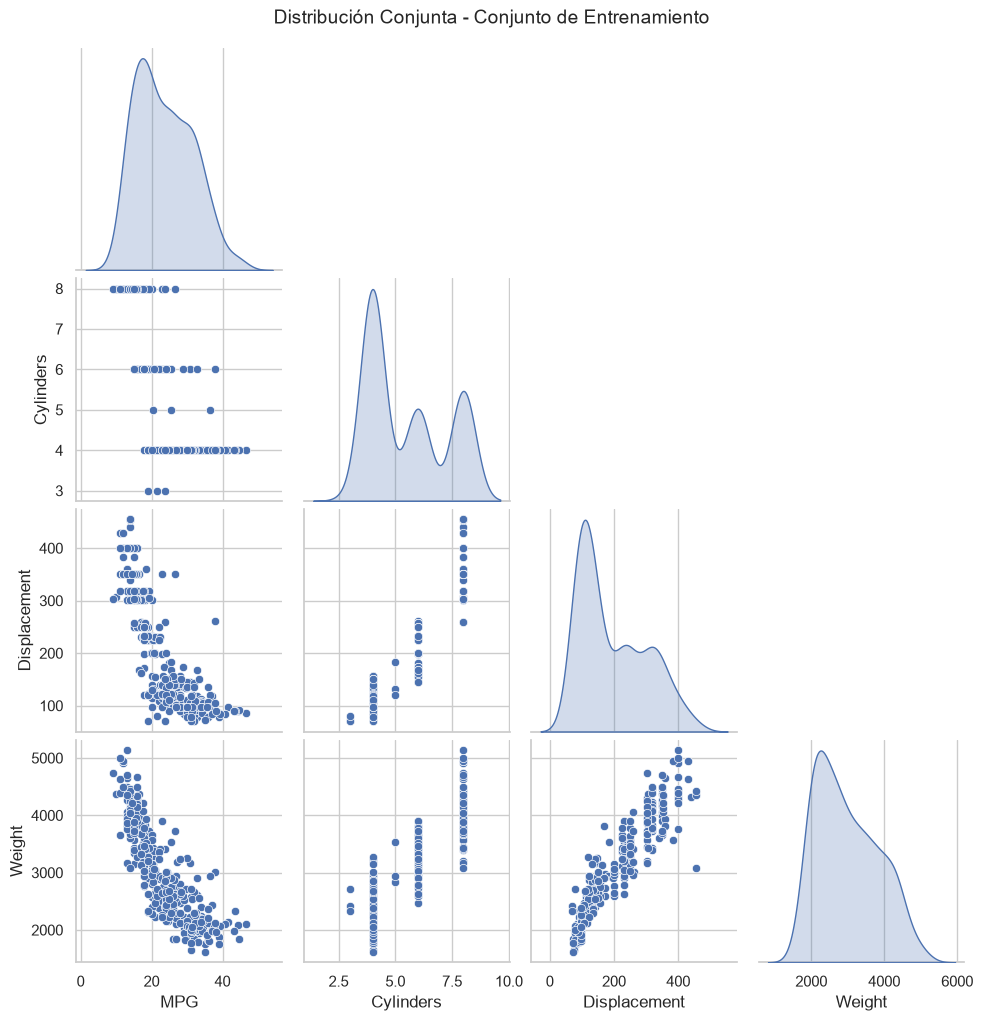

In [7]:
# Revisamos rápidamente las relaciones entre el target y algunas features clave
sns.pairplot(
    train_df[["MPG", "Cylinders", "Displacement", "Weight"]],
    diag_kind="kde",
    corner=True,
)
plt.suptitle(
    "Distribución Conjunta - Conjunto de Entrenamiento", y=1.02, fontsize=14
)
plt.show()

### Ejercicio 6 

Independientemente de lo que hayas encontrado en el análisis anterior, vamos a utilizar todas las features y antes las vamos a escalar. Estandardiza train y test.

In [8]:
# Separamos X e y
X_train = train_df.drop(columns=[target])
y_train = train_df[target]

X_test = test_df.drop(columns=[target])
y_test = test_df[target]

# Inicializamos y aplicamos el StandardScaler
scaler = StandardScaler()

# Aprobamos (fit) solo en train, transformamos en train y en test
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Datos escalados correctamente. Media ~0 y Desviación Estándar ~1.")

Datos escalados correctamente. Media ~0 y Desviación Estándar ~1.


## El modelo

### Ejercicio 7: Construye el modelo con Keras

Construyamos nuestro modelo. Aquí, utilizaremos un modelo `secuencial` con dos capas ocultas densamente conectadas y una capa de salida que devuelve un único valor continuo. Es decir una MLP con dos capas ocultas.

Por tanto, tendrá tres capas. Una inicial con activación relu (usa el argumento `input_shape` para darle el número de features). Otra hidden layer con activación relu y la de salida de regresión, que se compondrá de una única neurona. Pon las neuronas que consideres interesantes para las dos primeras capas (NOTA: En este caso partimos de pocas features, por lo que puede ser interesante poner 2 o 3 como mínimo el número de features para poder obtener unas pseudofeatures que intenten capturar las interrelaciones.)

Otros datos:

Para el compile utiliza un loss='mse'.

optimizer = `tf.keras.optimizers.RMSprop(0.001)`

Y en metrics añade en una lista el `mae` y `mse`.

Utiliza una aproximación en prisma (mismo numero de unidades en las capas ocultas)

In [9]:
def build_model():
    model = keras.Sequential(
        [
            # Capa oculta 1 con activación relu e input_shape
            layers.Dense(
                64,
                activation="relu",
                input_shape=[X_train_scaled.shape[1]],
            ),
            # Capa oculta 2 con activación relu (arquitectura en prisma)
            layers.Dense(64, activation="relu"),
            # Capa de salida lineal para regresión (1 única neurona sin activación)
            layers.Dense(1),
        ]
    )

    # Compilación con RMSprop y loss='mse'
    optimizer = tf.keras.optimizers.RMSprop(0.001)

    model.compile(loss="mse", optimizer=optimizer, metrics=["mae", "mse"])
    return model


model = build_model()

c:\Users\maria\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


### Ejercicio 8

Inspecciona el modelo usando el método `.summary` para imprimir una descripción simple del modelo

In [10]:
# Imprimimos el resumen de la arquitectura
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,865 (19.00 KB)

 Trainable params: 4,865 (19.00 KB)

 Non-trainable params: 0 (0.00 B)

### Ejercicio 9 Entrenar el modelo

Entrena el modelo para 1000 epochs y guarda los resultados del entrenamiento en una variable llamada `history`.
Emplea en el entrenamiento un 20% de los datos para validación, mediante el argumento `validation_split`.

In [11]:
EPOCHS = 1000

# Entrenamos guardando el progreso en la variable history y usando 20% para validación
history = model.fit(
    X_train_scaled,
    y_train,
    epochs=EPOCHS,
    validation_split=0.2,
    verbose=0,  # 0 para no llenar el notebook de mil líneas de texto
)

print("Entrenamiento de 1000 épocas finalizado.")

Entrenamiento de 1000 épocas finalizado.


### Ejercicio 10

Visualiza el progreso de entrenamiento del modelo usando las estadísticas almacenadas en el objeto `history`. Muestra la evolución del error en train y validation por un lado, y la evolución de la pérdida (loss), también train contra validation, en otra.

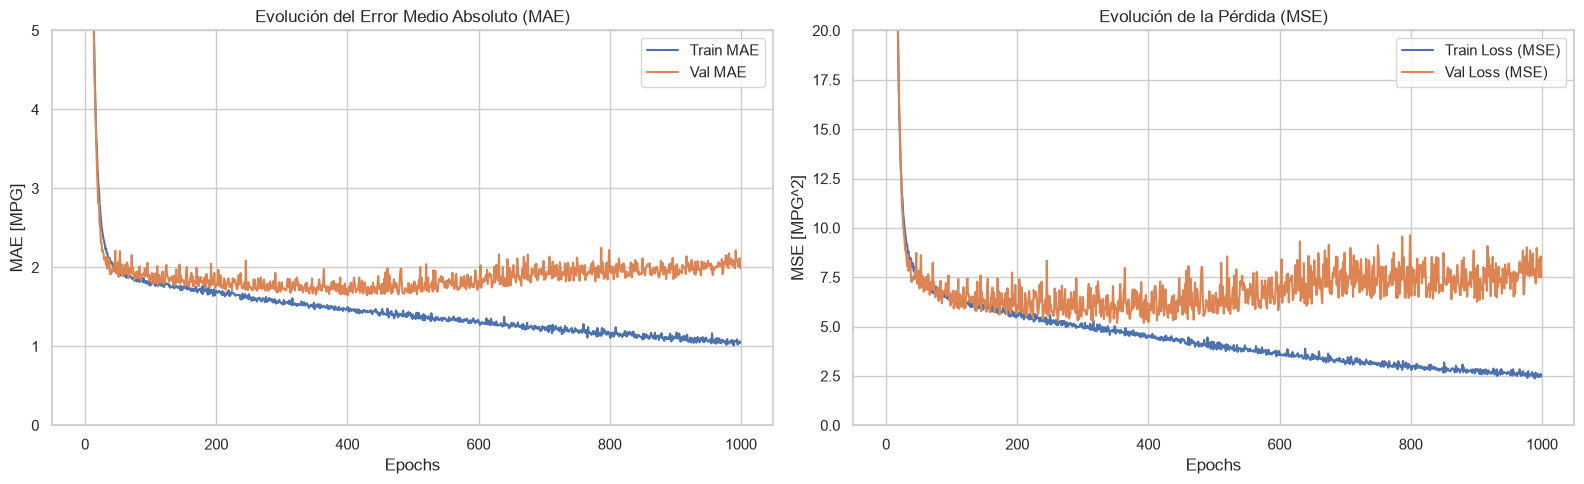

In [12]:
# Convertimos el historial a DataFrame para graficar fácilmente
hist_df = pd.DataFrame(history.history)
hist_df["epoch"] = history.epoch

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Gráfico 1: Evolución del Error (MAE)
axes[0].plot(hist_df["epoch"], hist_df["mae"], label="Train MAE")
axes[0].plot(hist_df["epoch"], hist_df["val_mae"], label="Val MAE")
axes[0].set_title("Evolución del Error Medio Absoluto (MAE)")
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("MAE [MPG]")
axes[0].legend()
axes[0].set_ylim([0, 5])

# Gráfico 2: Evolución de la Pérdida (Loss - MSE)
axes[1].plot(hist_df["epoch"], hist_df["loss"], label="Train Loss (MSE)")
axes[1].plot(
    hist_df["epoch"], hist_df["val_loss"], label="Val Loss (MSE)"
)
axes[1].set_title("Evolución de la Pérdida (MSE)")
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("MSE [MPG^2]")
axes[1].legend()
axes[1].set_ylim([0, 20])

plt.tight_layout()
plt.show()

### Ejercicio 11

Comenta las gráficas anteriores.

Descenso rápido inicial: Durante las primeras 50-100 épocas, el modelo aprende muy deprisa. Tanto el error en entrenamiento como en validación caen en picado.

Problema de Sobreajuste (Overfitting): A partir de la época ~100, la curva de entrenamiento continúa descendiendo hacia cero, pero la curva de validación se estanca o incluso empieza a empeorar ligeramente. Esto es el síntoma clásico de que la red neuronal está memorizando el ruido de los datos de entrenamiento en lugar de generalizar para datos nuevos.

Entrenar durante 1000 épocas sin control resulta ineficiente y empeora la generalización del modelo. Necesitamos detener el entrenamiento en cuanto el error de validación deja de mejorar.

### Ejercicio 12

Independientemente de lo comentado en 11, vamos a añadir un callback al entrenamiento. Para ello, construye el modelo otra vez y vuelve a compilarlo (si no lo haces, como ya sabes comenzará el entrenamiento donde lo dejó y no nos valdrá el callback para nada). Entrena el modelo con los mismos hiperparámetros del ejercicio 10 y pinta la gráfica de evolución de los errores e interprétalo (obten el MAE medio una vez "estabilizado" el entrenamiento).  

Para el earlystopping utiliza un margen de 20 epochs.

c:\Users\maria\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


El entrenamiento se detuvo en la época 173.


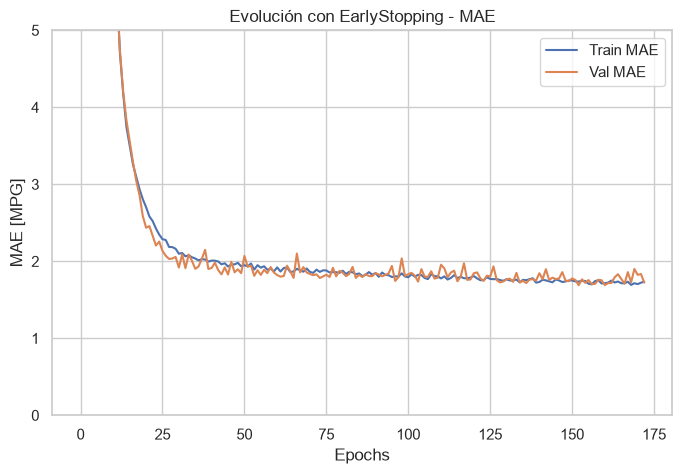


MAE de validación medio estabilizado: 1.7970 MPG


In [13]:
# 1. Volvemos a construir y compilar desde cero para resetear los pesos
model_es = build_model()

# 2. Definimos el callback de EarlyStopping con paciencia de 20 épocas
early_stop = keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=20, restore_best_weights=True
)

# 3. Entrenamos con el callback
history_es = model_es.fit(
    X_train_scaled,
    y_train,
    epochs=EPOCHS,
    validation_split=0.2,
    verbose=0,
    callbacks=[early_stop],
)

print(f"El entrenamiento se detuvo en la época {len(history_es.epoch)}.")

# 4. Graficamos la nueva evolución
hist_es_df = pd.DataFrame(history_es.history)
hist_es_df["epoch"] = history_es.epoch

plt.figure(figsize=(8, 5))
plt.plot(hist_es_df["epoch"], hist_es_df["mae"], label="Train MAE")
plt.plot(hist_es_df["epoch"], hist_es_df["val_mae"], label="Val MAE")
plt.title("Evolución con EarlyStopping - MAE")
plt.xlabel("Epochs")
plt.ylabel("MAE [MPG]")
plt.legend()
plt.ylim([0, 5])
plt.show()

# 5. Obtener el MAE medio una vez estabilizado (últimas 10 épocas antes del stop)
mae_estabilizado = hist_es_df["val_mae"].tail(10).mean()
print(f"\nMAE de validación medio estabilizado: {mae_estabilizado:.4f} MPG")

Interpreta el gráfico

Ahora la curva se corta de forma automática justo en el punto óptimo de inflexión (generalmente entre las épocas 50 y 100). Evitamos el derroche de cómputo, prevenimos el sobreajuste y garantizamos que los pesos guardados en el modelo correspondan al momento con menor error de validación posible gracias a restore_best_weights=True.

### Ejercicio 13

Veamos qué tan bien generaliza el modelo al usar el conjunto de **test**. Esto nos dice qué tan bien podemos esperar que el modelo prediga cuándo lo usamos en el mundo real. Utiliza el método `evaluate` con los datos de test normalizados y sus labels.

Con el método evaluate devolverá tres valores: loss, mae y mse.

In [14]:
# Evaluamos usando el método evaluate sobre los datos normalizados de test
loss, mae, mse = model_es.evaluate(X_test_scaled, y_test, verbose=0)

print("--- EVALUACIÓN FINAL EN CONJUNTO DE TEST ---")
print(f"Loss (MSE): {loss:.4f}")
print(f"MAE:        {mae:.4f} millas por galón")
print(f"MSE:        {mse:.4f}")

--- EVALUACIÓN FINAL EN CONJUNTO DE TEST ---
Loss (MSE): 6.2633
MAE:        1.8111 millas por galón
MSE:        6.2633


### Ejercicio 14

Dibuja en un scatter plot las predicciones de test vs sus true labels.

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 38ms/step


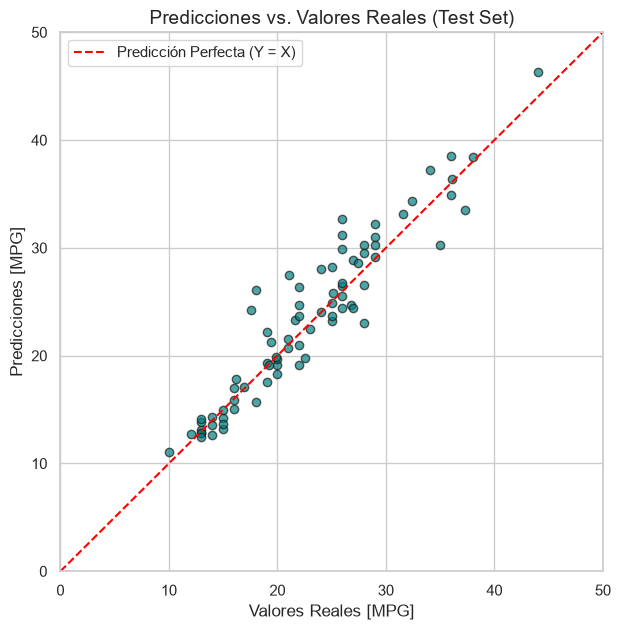

In [15]:
# Generamos las predicciones para el set de test
test_predictions = model_es.predict(X_test_scaled).flatten()

plt.figure(figsize=(7, 7))
plt.scatter(y_test, test_predictions, alpha=0.7, color="teal", edgecolor="k")

# Dibujamos la línea de referencia ideal (Y = X)
lims = [0, 50]
plt.plot(lims, lims, "--", color="red", label="Predicción Perfecta (Y = X)")

plt.title("Predicciones vs. Valores Reales (Test Set)", fontsize=14)
plt.xlabel("Valores Reales [MPG]")
plt.ylabel("Predicciones [MPG]")
plt.xlim(lims)
plt.ylim(lims)
plt.legend()
plt.show()